# SemEval-2026 Task 11 — Subtask 1: Syllogistic Reasoning (Binary Validity Classification)

## Top-Tier Neurosymbolic Pipeline

### Architecture Overview

This notebook implements an **agreement-gated neurosymbolic reasoning** system that directly addresses the core challenge of the task: separating **formal validity** from **semantic plausibility** (content effect).

Research grounding:
- **LINC (Neurosymbolic Reasoning)**: Semantic parser + external symbolic prover is the right architecture for logical reasoning tasks (OpenReview, EMNLP 2023)
- **Content effects in LLMs** (PMC 2024): Models confuse plausibility with validity — our symbolic core is immune to this because it never reads semantics
- **Counterfactual invariance** (OpenReview): Renaming terms should not change validity prediction — we train the fallback on abstracted/renamed syllogisms
- **Existential Import** (Utrecht University, EMNLP 2024): Modern vs Aristotelian semantics diverge on certain forms — we handle both
- **Meaningless hashing** (ScienceDirect 2025): Replacing bias-inducing words with neutral tokens reduces content effect in neural models

### Pipeline Stages
```
Syllogism text
      ↓
Stage A: Discourse-aware Segmenter + Canonicalizer
      ↓
Stage B: Dual Semantic Parser (High-precision Templates + T5 with Self-Consistency)
      ↓
Stage C: Conclusion-driven Role Mapping (Minor / Middle / Major)
      ↓
Stage D: Exact Symbolic SAT Solver (8-region Venn)
      ↓
Stage E: Dual Semantic Modes (Modern + Existential Import)
      ↓
Stage F: Calibrated Agreement-Gated Router
      ↓
Stage G: Counterfactually-Invariant Neural Fallback
      ↓
Final Validity Prediction
```

### Official Metric
The ranking metric is `ACC / (1 + ln(1 + TCE))` where TCE measures content effect. High accuracy AND low content bias are both required.

In [1]:
!pip -q install transformers datasets accelerate sentencepiece evaluate scikit-learn

import os
import random
import numpy as np
import torch
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [2]:
import zipfile
import json

ZIP_PATH = Path("/content/semeval_2026_task_11-main.zip")
EXTRACT_DIR = Path("/content/semeval_task11_extracted")
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
ROOT_DIR = EXTRACT_DIR / "semeval_2026_task_11-main"

if not ROOT_DIR.exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR)
    print(f"Extracted ZIP to: {EXTRACT_DIR}")
else:
    print(f"Already extracted. Using: {ROOT_DIR}")

TRAIN_PATH = ROOT_DIR / "train_data" / "subtask 1" / "train_data.json"
TEST_PATH  = ROOT_DIR / "test_data"  / "subtask 1" / "test_data_subtask_1.json"

assert TRAIN_PATH.exists(), f"Train file not found: {TRAIN_PATH}"
assert TEST_PATH.exists(),  f"Test file not found: {TEST_PATH}"

train_data = json.loads(TRAIN_PATH.read_text(encoding="utf-8"))
test_data = json.loads(TEST_PATH.read_text(encoding="utf-8"))

print("Train items:", len(train_data))
print("Test items :", len(test_data))
print("TRAIN_PATH :", TRAIN_PATH)
print("TEST_PATH  :", TEST_PATH)

print("\nExample train item:\n", train_data[0])
print("\nExample test item:\n", test_data[0])

Extracted ZIP to: /content/semeval_task11_extracted
Train items: 960
Test items : 191
TRAIN_PATH : /content/semeval_task11_extracted/semeval_2026_task_11-main/train_data/subtask 1/train_data.json
TEST_PATH  : /content/semeval_task11_extracted/semeval_2026_task_11-main/test_data/subtask 1/test_data_subtask_1.json

Example train item:
 {'id': '50146f21-d265-4e3a-8d93-8165cdbe89a3', 'syllogism': 'All cars are a type of vehicle. No animal is a car. Therefore, no animal can be a vehicle.', 'validity': False, 'plausibility': True}

Example test item:
 {'id': 'bff2af61-d4b0-4147-8a5b-ff4fe1892559', 'syllogism': 'There are no bikes that can be called cars. It is also true that every bike is a type of vehicle. This has led to the conclusion that a portion of vehicles are bikes.'}


In [3]:
from sklearn.model_selection import train_test_split

train_split, dev_split = train_test_split(
    train_data,
    test_size=0.15,
    random_state=SEED,
    stratify=[int(bool(x["validity"])) for x in train_data]
)

print(f"Train split: {len(train_split)} items")
print(f"Dev split  : {len(dev_split)} items")

train_valid_ratio = sum(1 for x in train_split if x["validity"]) / len(train_split)
dev_valid_ratio   = sum(1 for x in dev_split   if x["validity"]) / len(dev_split)
print(f"Valid ratio — Train: {train_valid_ratio:.3f} | Dev: {dev_valid_ratio:.3f}")

Train split: 816 items
Dev split  : 144 items
Valid ratio — Train: 0.500 | Dev: 0.500


In [4]:
import math
from collections import defaultdict

def compute_official_metrics(gold_items, pred_validities):
    correct = 0
    buckets = defaultdict(lambda: {"n": 0, "correct": 0})

    for g, pv in zip(gold_items, pred_validities):
        g_valid = bool(g["validity"])
        g_plaus = bool(g["plausibility"])
        p_valid = bool(pv)

        if g_valid == p_valid:
            correct += 1

        key = (g_valid, g_plaus)
        buckets[key]["n"] += 1
        if g_valid == p_valid:
            buckets[key]["correct"] += 1

    ACC = correct / max(1, len(gold_items))

    acc_groups = {}
    for key, stats in buckets.items():
        acc_groups[key] = stats["correct"] / stats["n"] if stats["n"] > 0 else 0.0

    diffs = []
    for validity_value in [True, False]:
        acc_plaus   = acc_groups.get((validity_value, True),  None)
        acc_implaus = acc_groups.get((validity_value, False), None)

        if acc_plaus is not None and acc_implaus is not None:
            diffs.append(abs(acc_plaus - acc_implaus))

    TCE = sum(diffs) / len(diffs) if diffs else 0.0

    RANK = ACC / (1.0 + math.log(1.0 + TCE))

    return {
        "ACC":        ACC,
        "TCE":        TCE,
        "RANK":       RANK,
        "acc_groups": acc_groups
    }

_test_gold = [{"validity": True,  "plausibility": True},
               {"validity": False, "plausibility": False}]
_test_pred = [True, False]
_smoke = compute_official_metrics(_test_gold, _test_pred)
assert abs(_smoke["ACC"] - 1.0) < 1e-9 and abs(_smoke["TCE"]) < 1e-9, "Metric smoke test failed!"

_test_gold = [{"validity": True,  "plausibility": True},
              {"validity": True,  "plausibility": False},
              {"validity": False, "plausibility": True},
              {"validity": False, "plausibility": False}]
_test_pred = [True, True, False, False]
_smoke = compute_official_metrics(_test_gold, _test_pred)
assert abs(_smoke["ACC"] - 1.0) < 1e-9 and abs(_smoke["TCE"]) < 1e-9, "Metric smoke test failed!"

In [5]:
import re

CONCLUSION_CUES = [
    "therefore",
    "thus",
    "hence",
    "so",
    "it follows that",
    "it logically follows that",
    "this implies that",
    "this shows that",
    "this proves that",
    "we can conclude that",
    "we conclude that",
    "this has led to the conclusion that",
    "as a result",
    "consequently",
]

CUE_RE = re.compile(
    "|".join(re.escape(c) for c in CONCLUSION_CUES),
    flags=re.I
)

LEADIN_PATTERNS = [
    r"^(it is|it's)\s+(true|a fact|the case)\s+that\s+",
    r"^it\s+is\s+also\s+true\s+that\s+",
    r"^as\s+a\s+result\s*,?\s+",
    r"^based\s+on\s+this\s*,?\s+",
    r"^(therefore|thus|hence|so|consequently)\s*,?\s+",
    r"^this\s+has\s+led\s+to\s+the\s+conclusion\s+that\s+",
    r"^without\s+exception\s*,?\s+",
    r"^in\s+other\s+words\s*,?\s+",
    r"^it\s+can\s+be\s+said\s+that\s+",
    r"^it\s+is\s+also\s+(the case|clear)\s+that\s+",
]

LEADIN_RE = [re.compile(p, flags=re.I) for p in LEADIN_PATTERNS]

NOT_TRUE_RE = re.compile(
    r"^(it\s+is\s+not\s+(true|the\s+case)\s+that|it's\s+not\s+true\s+that)\s+",
    flags=re.I
)

def clean_ws(x):
    x = x.strip()
    x = re.sub(r"\s+", " ", x)
    return x

def strip_leadins(x):
    x = clean_ws(x)
    changed = True
    while changed:
        changed = False
        for rgx in LEADIN_RE:
            m = rgx.match(x)
            if m:
                x = clean_ws(x[m.end():])
                changed = True
    return x

def normalize_copula(x):
    x = clean_ws(x)
    x = re.sub(r"\b(can be|could be|must be|will be|are always|is always|are called|can be called)\b",
                " IS ", x, flags=re.I)
    x = re.sub(r"\b(is|are|was|were|be)\b", " IS ", x, flags=re.I)
    x = clean_ws(x)
    return x

def normalize_term(t):
    t = clean_ws(t)
    t = t.strip(" ,;:.!?\"'()[]{}")
    t = re.sub(r"^(a|an|the)\s+", "", t, flags=re.I)
    t = re.sub(r"^(a\s+type\s+of|a\s+kind\s+of|a\s+sort\s+of)\s+", "", t, flags=re.I)
    t = clean_ws(t).lower()
    if len(t) > 3 and t.endswith("s") and not t.endswith("ss"):
        t = t[:-1]
    return t

def segment_syllogism(text):
    text = clean_ws(text)
    raw_parts = re.split(r"[.;]\s*", text)
    parts = [p.strip() for p in raw_parts if p.strip()]
    if len(parts) < 3:
        return None
    if len(parts) == 3:
        return parts[0], parts[1], parts[2]
    cue_indices = [i for i, s in enumerate(parts) if CUE_RE.search(s)]

    if cue_indices:
        c_idx = cue_indices[-1]
        p2_idx = max(0, c_idx - 1)
        p1_idx = max(0, c_idx - 2)
        return parts[p1_idx], parts[p2_idx], parts[c_idx]

    return parts[-3], parts[-2], parts[-1]

_ex = "It is true that no building is a vehicle. Each house, without exception, is a building. Therefore, no houses can be vehicles."
_seg = segment_syllogism(_ex)
assert _seg is not None, "Segmenter failed on basic example!"
print("Segmenter smoke test passed:")
print(f"  P1: {_seg[0]}")
print(f"  P2: {_seg[1]}")
print(f"  C : {_seg[2]}")

Segmenter smoke test passed:
  P1: It is true that no building is a vehicle
  P2: Each house, without exception, is a building
  C : Therefore, no houses can be vehicles


In [6]:
from dataclasses import dataclass

Q_ALL      = "ALL"
Q_NO       = "NO"
Q_SOME     = "SOME"
Q_SOME_NOT = "SOME_NOT"
Q_UNK      = "UNK"

def flip_quantifier(q):
    return {
        Q_ALL:      Q_SOME_NOT,
        Q_NO:       Q_SOME,
        Q_SOME:     Q_NO,
        Q_SOME_NOT: Q_ALL,
    }.get(q, Q_UNK)

@dataclass(frozen=True)
class Proposition:
    q: str
    s: str
    p: str

@dataclass(frozen=True)
class ParseResult:
    prop: Proposition
    conf: float
    src:  str

class TemplateParser:
    def __init__(self):

        self.rules = []

        def add(name, pattern, q, base_conf):
            self.rules.append((name, re.compile(pattern, flags=re.I), q, base_conf))

        add("ALL_all",          r"^all\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",                 Q_ALL, 0.97)
        add("ALL_every",        r"^every\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",               Q_ALL, 0.97)
        add("ALL_each",         r"^each\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",                Q_ALL, 0.96)
        add("ALL_every_single", r"^every\s+single\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",     Q_ALL, 0.95)
        add("ALL_without_exc",  r"^without\s+exception.*?(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",Q_ALL, 0.90)

        add("NO_no",           r"^no\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",                  Q_NO, 0.97)
        add("NO_none_of",      r"^none\s+of\s+(the\s+)?(?P<S>.+?)\s+IS\s+(?P<P>.+?)$", Q_NO, 0.94)
        add("NO_not_a_single", r"^not\s+a\s+single\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",   Q_NO, 0.95)
        add("NO_there_are_no", r"^there\s+(are|exist|IS)\s+no\s+(?P<S>.+?)\s+(that\s+)?IS\s+(?P<P>.+?)$", Q_NO, 0.93)
        add("NO_never",        r"^(?P<S>.+?)\s+IS\s+never\s+(?P<P>.+?)$",               Q_NO, 0.90)

        add("SOME_some",       r"^some\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",                Q_SOME, 0.96)
        add("SOME_there_are",r"^there\s+(are|exist|IS)\s+(some\s+)?(?P<S>.+?)\s+(that\s+)?IS\s+(?P<P>.+?)$",Q_SOME, 0.92)
        add("SOME_portion",    r"^(a\s+)?portion\s+of\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",Q_SOME, 0.92)
        add("SOME_at_least",   r"^at\s+least\s+one\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",   Q_SOME, 0.94)
        add("SOME_certain",    r"^(certain|many|most|several)\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",
            Q_SOME, 0.88)

        add("SOME_NOT_some_not",  r"^some\s+(?P<S>.+?)\s+IS\s+not\s+(?P<P>.+?)$",       Q_SOME_NOT, 0.97)
        add("SOME_NOT_not_all",   r"^not\s+all\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",        Q_SOME_NOT, 0.95)
        add("SOME_NOT_not_every", r"^not\s+every\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",      Q_SOME_NOT, 0.95)
        add("SOME_NOT_not_each",  r"^not\s+each\s+(?P<S>.+?)\s+IS\s+(?P<P>.+?)$",       Q_SOME_NOT, 0.94)

    def parse(self, raw_sentence):
        s = clean_ws(raw_sentence)

        s = strip_leadins(s)
        flipped = False
        m = NOT_TRUE_RE.match(s)
        if m:
            flipped = True
            s = clean_ws(s[m.end():])
            s = strip_leadins(s)

        s_norm = normalize_copula(s)

        best = None
        for name, rgx, q, base_conf in self.rules:
            mm = rgx.match(s_norm)
            if not mm:
                continue

            subj = normalize_term(mm.group("S"))
            pred = normalize_term(mm.group("P"))

            if not subj or not pred or subj == pred:
                continue
            qq = flip_quantifier(q) if flipped else q

            conf = min(base_conf, 0.90) if flipped else base_conf

            cand = ParseResult(
                prop=Proposition(qq, subj, pred),
                conf=conf,
                src=f"TEMPLATE:{name}"
            )

            if best is None or cand.conf > best.conf:
                best = cand

        if best is None:
            return ParseResult(Proposition(Q_UNK, "", ""), 0.0, "FAIL")

        return best

tmpl_parser = TemplateParser()
_tr = tmpl_parser.parse("It is true that no building is a vehicle.")
print(f"Template parse smoke test: {_tr}")
assert _tr.prop.q == Q_NO, f"Expected Q_NO but got {_tr.prop.q}"
print("Template parser smoke test passed.")

Template parse smoke test: ParseResult(prop=Proposition(q='NO', s='building', p='vehicle'), conf=0.97, src='TEMPLATE:NO_no')
Template parser smoke test passed.


In [7]:
DSL_RE = re.compile(
    r"^Q=(ALL|NO|SOME|SOME_NOT)\s*;\s*S=(.+?)\s*;\s*P=(.+?)\s*$"
)

def parse_dsl_string(s):
    s = s.strip()
    m = DSL_RE.match(s)
    if not m:
        return None

    q    = m.group(1)
    subj = normalize_term(m.group(2))
    pred = normalize_term(m.group(3))
    if not subj or not pred or subj == pred:
        return None

    return Proposition(q, subj, pred)

In [8]:
def role_mapping(p1, p2, c):

    minor = c.s
    major = c.p

    terms_p1 = {p1.s, p1.p}
    terms_p2 = {p2.s, p2.p}

    middle_candidates = (terms_p1 & terms_p2) - {minor, major}
    if len(middle_candidates) != 1:
        return None

    middle = list(middle_candidates)[0]
    return {
        minor:  "A",
        middle: "B",
        major:  "C",
    }

def term_stability_score(p1, p2, c):
    all_terms = sorted(set([p1.s, p1.p, p2.s, p2.p, c.s, c.p]))
    if len(all_terms) == 3:
        return 1.0
    if len(all_terms) == 4:
        return 0.5
    return 0.0

def parser_agreement_score(template_res, neural_res):
    if template_res.prop.q == Q_UNK or neural_res.prop.q == Q_UNK:
        return 0.0

    return float(template_res.prop == neural_res.prop)

def parse_statement_dual(sentence, t5_K=11):
    r_template = tmpl_parser.parse(sentence)
    r_t5 = t5_parse_statement_self_consistency(sentence, K=t5_K)

    if r_template.prop.q != Q_UNK:
        chosen = r_template
    else:
        chosen = r_t5

    return chosen, r_template, r_t5

# smoke test
_p1 = Proposition(Q_ALL, "mortal", "thing")
_p2 = Proposition(Q_ALL, "human",  "mortal")
_c  = Proposition(Q_ALL, "human",  "thing")
_mapping = role_mapping(_p1, _p2, _c)
print(f"  Mapping: {_mapping}")
assert _mapping is not None and _mapping["human"] == "A", "Role mapping smoke test failed!"
print("Role mapping smoke test passed.")

  Mapping: {'human': 'A', 'mortal': 'B', 'thing': 'C'}
Role mapping smoke test passed.


In [9]:
REGIONS = [(a, b, c) for a in (0, 1) for b in (0, 1) for c in (0, 1)]

def bit(term_label, region):
    a, b, c = region
    return {"A": a, "B": b, "C": c}[term_label]

def negate_prop(p):
    return Proposition(flip_quantifier(p.q), p.s, p.p)

def constraints_for_prop(p, mapping):
    q = p.q
    S = mapping[p.s]
    P = mapping[p.p]

    empties = []
    exists  = []

    for r in REGIONS:
        s_in = bit(S, r)
        p_in = bit(P, r)

        if q == Q_ALL and s_in == 1 and p_in == 0:
            empties.append(r)

        elif q == Q_NO and s_in == 1 and p_in == 1:
            empties.append(r)

        elif q == Q_SOME and s_in == 1 and p_in == 1:
            exists.append(r)

        elif q == Q_SOME_NOT and s_in == 1 and p_in == 0:
            exists.append(r)

    return empties, exists

def satisfiable(props, mapping, existential_import=False):
    forced_empty = set()
    exist_sets = []

    for p in props:
        empties, exists = constraints_for_prop(p, mapping)
        forced_empty.update(empties)
        if len(exists) > 0:
            exist_sets.append(exists)

    if existential_import:
        for p in props:
            if p.q in (Q_ALL, Q_NO):
                S = mapping[p.s]
                ex = [r for r in REGIONS if bit(S, r) == 1]
                exist_sets.append(ex)

    for ex in exist_sets:
        if all(r in forced_empty for r in ex):
            return False

    if len(exist_sets) == 0:
        return True

    free = [r for r in REGIONS if r not in forced_empty]
    n = len(free)

    for mask in range(1 << n):
        chosen = {free[i] for i in range(n) if (mask >> i) & 1}
        ok = True
        for ex in exist_sets:
            if not any(r in chosen for r in ex):
                ok = False
                break

        if ok:
            return True

    return False

def entails(premises, conclusion, mapping, existential_import=False):
    return not satisfiable(
        list(premises) + [negate_prop(conclusion)],
        mapping,
        existential_import=existential_import
    )

def predict_symbolic_dual_modes(premises, conclusion, mapping):
    v_modern = entails(premises, conclusion, mapping, existential_import=False)
    v_ei     = entails(premises, conclusion, mapping, existential_import=True)
    agree    = (v_modern == v_ei)
    return v_modern, v_ei, agree

_barbara_mapping = {"S": "A", "M": "B", "P": "C"}
_barbara_p1 = Proposition(Q_ALL, "M", "P")
_barbara_p2 = Proposition(Q_ALL, "S", "M")
_barbara_c  = Proposition(Q_ALL, "S", "P")

_v_m, _v_ei, _ag = predict_symbolic_dual_modes(
    [_barbara_p1, _barbara_p2], _barbara_c, _barbara_mapping
)
print(f"Barbara (AAA-1) Modern: {_v_m}, EI: {_v_ei}, Agree: {_ag}")
assert _v_m == True  and _v_ei == True,  "Barbara should be valid!"

_invalid_p1 = Proposition(Q_ALL, "M", "P")
_invalid_p2 = Proposition(Q_ALL, "M", "S")
_invalid_c  = Proposition(Q_ALL, "S", "P")
_invalid_mapping = {"S": "A", "M": "B", "P": "C"}
_vi_m, _vi_ei, _ = predict_symbolic_dual_modes(
    [_invalid_p1, _invalid_p2], _invalid_c, _invalid_mapping
)
print(f"Invalid form Modern: {_vi_m}, EI: {_vi_ei}")
assert _vi_m == False, "Undistributed middle should be invalid in modern logic!"
print("Solver smoke tests passed.")

Barbara (AAA-1) Modern: True, EI: True, Agree: True
Invalid form Modern: False, EI: False
Solver smoke tests passed.


In [10]:
import itertools

TERMS = ["wug", "zorb", "blicket", "dax", "toma", "glorp", "mip", "teel",
          "fep", "kiki", "bouba", "speff", "norp", "vish", "grale", "quom"]

PARA = {
    Q_ALL: [
        "All {S} are {P}.",
        "Every {S} is {P}.",
        "Each {S} is {P}.",
        "Every single {S} is a {P}.",
        "It is true that all {S} are {P}.",
        "{S} are always {P}.",
        "Without exception, every {S} is {P}.",
    ],
    Q_NO: [
        "No {S} are {P}.",
        "No {S} is {P}.",
        "There are no {S} that are {P}.",
        "Not a single {S} is {P}.",
        "None of the {S} are {P}.",
        "It is true that no {S} are {P}.",
    ],
    Q_SOME: [
        "Some {S} are {P}.",
        "Some {S} is {P}.",
        "A portion of {S} are {P}.",
        "There are {S} that are {P}.",
        "At least one {S} is {P}.",
        "It is true that some {S} are {P}.",
    ],
    Q_SOME_NOT: [
        "Some {S} are not {P}.",
        "Not all {S} are {P}.",
        "Not every {S} is {P}.",
        "It is not true that all {S} are {P}.",
        "Some {S} are not {P}.",
        "Not each {S} is {P}.",
    ],
}

CONC_CUES = [
    "Therefore, ", "Thus, ", "Hence, ", "So, ",
    "It follows that ", "This implies that ",
    "We can conclude that ", "This has led to the conclusion that ",
    "As a result, ",
]
SYLLOGISM_PATTERNS = [
    # Barbara (AAA-1): All M are P, All S are M ⊨ All S are P
    ((Q_ALL,  "S", "M"), (Q_ALL,  "M", "P"), (Q_ALL,  "S", "P"), True),
    # Celarent (EAE-1): No M are P, All S are M ⊨ No S are P
    ((Q_NO,   "M", "P"), (Q_ALL,  "S", "M"), (Q_NO,   "S", "P"), True),
    # Darii (AII-1): All M are P, Some S are M ⊨ Some S are P
    ((Q_ALL,  "M", "P"), (Q_SOME, "S", "M"), (Q_SOME, "S", "P"), True),
    # Ferio (EIO-1): No M are P, Some S are M ⊨ Some S are not P
    ((Q_NO,   "M", "P"), (Q_SOME, "S", "M"), (Q_SOME_NOT, "S", "P"), True),
    # Cesare (EAE-2): No P are M, All S are M ⊨ No S are P
    ((Q_NO,   "P", "M"), (Q_ALL,  "S", "M"), (Q_NO,   "S", "P"), True),
    # Camestres (AEE-2): All P are M, No S are M ⊨ No S are P
    ((Q_ALL,  "P", "M"), (Q_NO,   "S", "M"), (Q_NO,   "S", "P"), True),
    # Disamis (IAI-3): Some M are P, All M are S ⊨ Some S are P
    ((Q_SOME, "M", "P"), (Q_ALL,  "M", "S"), (Q_SOME, "S", "P"), True),
    # Datisi (AII-3): All M are P, Some M are S ⊨ Some S are P
    ((Q_ALL,  "M", "P"), (Q_SOME, "M", "S"), (Q_SOME, "S", "P"), True),
    # Festino (EIO-2): No P are M, Some S are M ⊨ Some S are not P
    ((Q_NO, "P", "M"), (Q_SOME, "S", "M"), (Q_SOME_NOT, "S", "P"), True),

    # Undistributed middle: All P are M, All S are M → All S are P (INVALID)
    ((Q_ALL,  "P", "M"), (Q_ALL,  "S", "M"), (Q_ALL,  "S", "P"), False),
    # Illicit major: All M are P, No M are S → No S are P (INVALID)
    ((Q_ALL,  "M", "P"), (Q_NO,   "M", "S"), (Q_NO,   "S", "P"), False),
    # Wrong conclusion quantifier: All M are P, All S are M → Some P are S (INVALID)
    ((Q_ALL,  "M", "P"), (Q_ALL,  "S", "M"), (Q_SOME, "P", "S"), False),
    # Some + Some → All (INVALID — two particulars cannot give a universal)
    ((Q_SOME, "S", "M"), (Q_SOME, "M", "P"), (Q_ALL,  "S", "P"), False),
    # Some + All → No (INVALID)
    ((Q_SOME, "S", "M"), (Q_ALL,  "M", "P"), (Q_NO,   "S", "P"), False),
    # All + All → Some_Not (INVALID — contradicts Barbara)
    ((Q_ALL,  "S", "M"), (Q_ALL,  "M", "P"), (Q_SOME_NOT, "S", "P"), False),
    # No + No → All (INVALID — two negatives give nothing)
    ((Q_NO,   "S", "M"), (Q_NO,   "M", "P"), (Q_ALL,  "S", "P"), False),
    # Reversed conclusion: All S are M, All M are P → All P are S (INVALID — illicit conversion)
    ((Q_ALL,  "S", "M"), (Q_ALL,  "M", "P"), (Q_ALL,  "P", "S"), False),
]

def render_statement(q, S_term, P_term, is_conclusion=False):
    templ = random.choice(PARA[q])
    stmt = templ.format(S=S_term, P=P_term)
    if is_conclusion:
        stmt_body = stmt.rstrip(".")
        cue = random.choice(CONC_CUES)
        stmt = cue + stmt_body[0].lower() + stmt_body[1:] + "."
    return stmt

def make_one_synthetic_syllogism():
    (q1, r11, r12), (q2, r21, r22), (q3, r31, r32), validity = random.choice(SYLLOGISM_PATTERNS)
    S_term, M_term, P_term = random.sample(TERMS, 3)
    sym2term = {"S": S_term, "M": M_term, "P": P_term}
    s1 = render_statement(q1, sym2term[r11], sym2term[r12], is_conclusion=False)
    s2 = render_statement(q2, sym2term[r21], sym2term[r22], is_conclusion=False)
    s3 = render_statement(q3, sym2term[r31], sym2term[r32], is_conclusion=True)
    if random.random() < 0.3:
        s1, s2 = s2, s1

    full_text = " ".join([s1, s2, s3])

    return {
        "syllogism":    full_text,
        "validity":     bool(validity),
        "plausibility": False
    }

def build_synthetic_syllogism_dataset(n=15000):
    examples = [make_one_synthetic_syllogism() for _ in range(n)]
    n_valid   = sum(1 for e in examples if e["validity"])
    n_invalid = n - n_valid
    print(f"Synthetic dataset: {n} total | {n_valid} valid | {n_invalid} invalid")
    return examples

synthetic_syllogisms = build_synthetic_syllogism_dataset(n=15000)
print("Example synthetic syllogism:")
print(synthetic_syllogisms[0])

Synthetic dataset: 15000 total | 7903 valid | 7097 invalid
Example synthetic syllogism:
{'syllogism': 'No speff is toma. Some wug is speff. Thus, not all wug are toma.', 'validity': True, 'plausibility': False}


In [11]:
from transformers import T5ForConditionalGeneration, T5Tokenizer

T5_MODEL = "t5-small"

t5_tok = T5Tokenizer.from_pretrained(T5_MODEL)
t5_m   = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)

print(f"Loaded {T5_MODEL}")
print(f"Params: {sum(p.numel() for p in t5_m.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded t5-small
Params: 60,506,624


In [12]:
from datasets import Dataset
from transformers import DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

def make_dsl_target(q, S, P):
    return f"Q={q}; S={S}; P={P}"

def build_t5_training_pairs_from_synthetics(synthetic_items, n_direct=20000):
    X, Y = [], []
    for ex in synthetic_items:
        seg = segment_syllogism(ex["syllogism"])
        if seg is None:
            continue
        for sent in seg:
            r = tmpl_parser.parse(sent)
            if r.prop.q == Q_UNK:
                continue
            if r.conf < 0.85:
                continue

            X.append(strip_leadins(clean_ws(sent)))
            Y.append(make_dsl_target(r.prop.q, r.prop.s, r.prop.p))

    for _ in range(n_direct):
        q = random.choice([Q_ALL, Q_NO, Q_SOME, Q_SOME_NOT])
        S_term, P_term = random.sample(TERMS, 2)
        templ = random.choice(PARA[q])
        sent = templ.format(S=S_term, P=P_term)

        r = tmpl_parser.parse(sent)
        if r.prop.q == Q_UNK:
            continue

        X.append(strip_leadins(clean_ws(sent)))
        Y.append(make_dsl_target(r.prop.q, r.prop.s, r.prop.p))

    print(f"T5 training pairs: {len(X)} total")
    return X, Y

X_dsl, Y_dsl = build_t5_training_pairs_from_synthetics(synthetic_syllogisms, n_direct=20000)

dsl_ds = Dataset.from_dict({"src": X_dsl, "tgt": Y_dsl})

def tok_dsl(batch):
    model_inputs = t5_tok(
        batch["src"],
        truncation=True,
        padding="max_length",
        max_length=64
    )
    labels = t5_tok(
        batch["tgt"],
        truncation=True,
        padding="max_length",
        max_length=32
    )
    model_inputs["labels"] = [
        [-100 if token == t5_tok.pad_token_id else token for token in ids]
        for ids in labels["input_ids"]
    ]
    return model_inputs

dsl_ds = dsl_ds.map(tok_dsl, batched=True, remove_columns=["src", "tgt"])
collator = DataCollatorForSeq2Seq(tokenizer=t5_tok, model=t5_m)

t5_train_args = Seq2SeqTrainingArguments(
    output_dir="/content/t5_dsl_out",
    learning_rate=3e-4,
    per_device_train_batch_size=32,
    num_train_epochs=3,
    logging_steps=200,
    save_steps=1000,
    report_to="none",
    seed=SEED,
    predict_with_generate=True,
)

t5_trainer = Seq2SeqTrainer(
    model=t5_m,
    args=t5_train_args,
    train_dataset=dsl_ds,
    processing_class=t5_tok,
    data_collator=collator,
)

t5_trainer.train()
t5_m.save_pretrained("/content/t5_dsl_finetuned")
t5_tok.save_pretrained("/content/t5_dsl_finetuned")

print(f"Training dataset size: {len(dsl_ds)}")

T5 training pairs: 56587 total


Map:   0%|          | 0/56587 [00:00<?, ? examples/s]

Step,Training Loss
200,0.215225
400,0.001595
600,0.000889
800,0.000736
1000,0.000162
1200,0.000109
1400,0.000748
1600,0.000134
1800,0.000520
2000,0.000315


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training dataset size: 56587


In [13]:
from collections import Counter

In [14]:
@torch.no_grad()
def t5_parse_statement_self_consistency(sentence: str, K: int = 7):
    t5_m.eval()

    input_text = strip_leadins(clean_ws(sentence))

    enc = t5_tok(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=64
    ).to(DEVICE)

    outputs = t5_m.generate(
        **enc,
        max_new_tokens=32,
        do_sample=True,
        temperature=0.7,
        num_return_sequences=K
    )

    parsed_props = []

    for out in outputs:
        decoded = t5_tok.decode(out, skip_special_tokens=True).strip()
        p = parse_dsl_string(decoded)

        if p is None:
            p = Proposition(q=Q_UNK, s="", p="")

        parsed_props.append(p)

    q_votes = Counter(p.q for p in parsed_props if p.q != Q_UNK)

    if not q_votes:
        best_q = Q_UNK
    else:
        best_q = q_votes.most_common(1)[0][0]

    sp_votes = Counter(
        (p.s, p.p) for p in parsed_props if p.q == best_q
    )

    if sp_votes:
        best_s, best_p = sp_votes.most_common(1)[0][0]
    else:
        best_s, best_p = "", ""

    best_prop = Proposition(q=best_q, s=best_s, p=best_p)

    conf = q_votes.get(best_q, 0) / K if K > 0 else 0.0

    return ParseResult(best_prop, float(conf), "T5")

In [15]:
def extract_three_terms_from_props(p1, p2, c):
    return sorted(set([p1.s, p1.p, p2.s, p2.p, c.s, c.p]))

def rename_terms_in_text(text, term_list, new_terms):
    out = text
    for old, new in zip(term_list, new_terms):
        out = re.sub(rf"\b{re.escape(old)}\b", new, out, flags=re.I)
    return out

def abstract_to_T1_T2_T3(text, term_list):
    mapping = {}
    for i, term in enumerate(sorted(term_list)):
        mapping[term] = f"T{i+1}"

    out = text
    for old, new in mapping.items():
        out = re.sub(rf"\b{re.escape(old)}\b", new, out, flags=re.I)
    return out

def propositions_to_skeleton(p1, p2, c):
    all_terms = sorted(set([p1.s, p1.p, p2.s, p2.p, c.s, c.p]))
    t_map = {t: f"T{i+1}" for i, t in enumerate(all_terms)}

    def fmt(p):
        return f"{p.q}({t_map.get(p.s, p.s)},{t_map.get(p.p, p.p)})"

    return f"{fmt(p1)} || {fmt(p2)} -> {fmt(c)}"

def build_fallback_training_pairs(items, t5_K=7, num_counterfactual=3):
    X, y = [], []

    for ex in items:
        seg = segment_syllogism(ex["syllogism"])
        if seg is None:
            continue

        s1, s2, s3 = seg
        r1, _, _ = parse_statement_dual(s1, t5_K=t5_K)
        r2, _, _ = parse_statement_dual(s2, t5_K=t5_K)
        r3, _, _ = parse_statement_dual(s3, t5_K=t5_K)

        if any(r.prop.q == Q_UNK for r in [r1, r2, r3]):
            continue

        p1, p2, c = r1.prop, r2.prop, r3.prop

        terms = extract_three_terms_from_props(p1, p2, c)
        if len(terms) != 3:
            continue

        label = int(bool(ex["validity"]))
        base_text = ex["syllogism"].lower()
        X.append(abstract_to_T1_T2_T3(base_text, terms))
        y.append(label)
        X.append(propositions_to_skeleton(p1, p2, c))
        y.append(label)
        for k in range(num_counterfactual):
            new_terms = [f"wug{k}", f"zorb{k}", f"blicket{k}"]
            cf = rename_terms_in_text(base_text, terms, new_terms)
            X.append(cf)
            y.append(label)

    return X, y


def build_fallback_from_synthetic(synthetic_items):
    X, y = [], []
    for ex in synthetic_items:
        text = ex["syllogism"].lower()
        seg  = segment_syllogism(ex["syllogism"])
        if seg is None:
            continue
        s1, s2, s3 = seg
        r1, _, _ = parse_statement_dual(s1, t5_K=5)
        r2, _, _ = parse_statement_dual(s2, t5_K=5)
        r3, _, _ = parse_statement_dual(s3, t5_K=5)
        if any(r.prop.q == Q_UNK for r in [r1, r2, r3]):
            continue
        p1, p2, c = r1.prop, r2.prop, r3.prop
        X.append(propositions_to_skeleton(p1, p2, c))
        y.append(int(bool(ex["validity"])))
        X.append(text)
        y.append(int(bool(ex["validity"])))
    return X, y

X_fb_official, y_fb_official = build_fallback_training_pairs(
    train_split, t5_K=5, num_counterfactual=3
)

X_fb_synth, y_fb_synth = build_fallback_from_synthetic(synthetic_syllogisms[:5000])

X_fb = X_fb_official + X_fb_synth
y_fb = y_fb_official + y_fb_synth

print(f"\nTotal fallback training examples: {len(X_fb)}")
print(f"\nFrom official data: {len(X_fb_official)}")
print(f"\nFrom synthetic: {len(X_fb_synth)}")
print(f"\nPositive ratio: {sum(y_fb)/len(y_fb):.3f}")
print(f"\nExample fallback inputs:")
print(f"\nT1/T2/T3 abstracted: {X_fb[0][:80]}")
print(f"\nSkeleton: {X_fb[1]}")


Total fallback training examples: 10150

From official data: 150

From synthetic: 10000

Positive ratio: 0.529

Example fallback inputs:

T1/T2/T3 abstracted: anything that is a T3 is also an T1. a portion of animals are lizards. therefore

Skeleton: ALL(T3,T1) || SOME(T1,T2) -> SOME_NOT(T2,T3)


In [17]:
from transformers import AutoTokenizer as AutoTok
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.model_selection import train_test_split as sk_split
from datasets import Dataset as HFDataset

FB_MODEL_ID = "distilroberta-base"

X_fb_train, X_fb_dev, y_fb_train, y_fb_dev = sk_split(
    X_fb,
    y_fb,
    test_size=0.15,
    random_state=SEED,
    stratify=y_fb
)

ds_fb_train = HFDataset.from_dict({"text": X_fb_train, "label": y_fb_train})
ds_fb_dev   = HFDataset.from_dict({"text": X_fb_dev,   "label": y_fb_dev})

fb_tok = AutoTok.from_pretrained(FB_MODEL_ID)

def tok_fb_batch(batch):
    return fb_tok(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

ds_fb_train = ds_fb_train.map(tok_fb_batch, batched=True)
ds_fb_dev   = ds_fb_dev.map(tok_fb_batch, batched=True)

fb_model = AutoModelForSequenceClassification.from_pretrained(
    FB_MODEL_ID,
    num_labels=2
).to(DEVICE)

def compute_fb_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = float((preds == labels).mean())
    return {"acc": acc}

fb_args = TrainingArguments(
    output_dir="/content/fb_out",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="acc",
    logging_steps=100,
    seed=SEED,
    report_to="none"
)

fb_trainer = Trainer(
    model=fb_model,
    args=fb_args,
    train_dataset=ds_fb_train,
    eval_dataset=ds_fb_dev,
    processing_class=fb_tok,
    compute_metrics=compute_fb_metrics,
)

fb_trainer.train()

fb_model.save_pretrained("/content/fb_finetuned")
fb_tok.save_pretrained("/content/fb_finetuned")

FB_IS_TRAINED = True

print("Fallback classifier training complete.")
print(f"Train: {len(ds_fb_train)} | Dev: {len(ds_fb_dev)}")
print(f"FB_IS_TRAINED={FB_IS_TRAINED}")

Map:   0%|          | 0/8627 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Acc
1,0.346637,0.290700,0.868024
2,0.226165,0.115621,0.959291
3,0.093358,0.069470,0.981615


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fallback classifier training complete.
Train: 8627 | Dev: 1523
FB_IS_TRAINED=True


In [18]:
CALIB_T5_K = 11

In [19]:
@torch.no_grad()
def fallback_predict_validity(text):
    enc = fb_tok(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(DEVICE)

    logits = fb_model(**enc).logits.squeeze(0)
    probs = torch.softmax(logits, dim=-1)
    prob_valid = probs[1].item()

    return bool(prob_valid >= 0.5), float(prob_valid)


def fallback_with_abstraction(syllogism_text, parsed_props=None):
    if parsed_props is not None:
        p1, p2, c = parsed_props
        skeleton = propositions_to_skeleton(p1, p2, c)
        return fallback_predict_validity(skeleton)[0]
    else:
        return fallback_predict_validity(syllogism_text.lower())[0]


def router_predict_one(syllogism, tau_parse=0.70, t5_K=11):
    seg = segment_syllogism(syllogism)
    if seg is None:
        return fallback_predict_validity(syllogism.lower())[0]

    s1, s2, s3 = seg

    r1, r1_tmpl, r1_t5 = parse_statement_dual(s1, t5_K=t5_K)
    r2, r2_tmpl, r2_t5 = parse_statement_dual(s2, t5_K=t5_K)
    r3, r3_tmpl, r3_t5 = parse_statement_dual(s3, t5_K=t5_K)

    p1, p2, c = r1.prop, r2.prop, r3.prop

    if any(p.q == Q_UNK for p in [p1, p2, c]):
        return fallback_predict_validity(syllogism.lower())[0]

    mapping = role_mapping(p1, p2, c)
    if mapping is None:
        return fallback_predict_validity(syllogism.lower())[0]

    parse_conf = float(min(r1.conf, r2.conf, r3.conf))
    stability = float(term_stability_score(p1, p2, c))

    if parse_conf < tau_parse or stability < 1.0:
        return fallback_predict_validity(syllogism.lower())[0]

    v_modern, v_ei, modes_agree = predict_symbolic_dual_modes([p1, p2], c, mapping)

    if modes_agree:
        return bool(v_modern)

    return fallback_predict_validity(syllogism.lower())[0]


taus = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]

best_metrics = None
best_tau = 0.70

for tau in taus:
    preds = [
        router_predict_one(ex["syllogism"], tau_parse=tau, t5_K=CALIB_T5_K)
        for ex in dev_split
    ]

    m = compute_official_metrics(dev_split, preds)

    print(
        f"tau={tau:.2f} → "
        f"ACC={m['ACC']:.4f}, "
        f"TCE={m['TCE']:.4f}, "
        f"RANK={m['RANK']:.4f}"
    )

    if best_metrics is None or m["RANK"] > best_metrics["RANK"]:
        best_metrics = m
        best_tau = tau

print(f"\nBest tau_parse: {best_tau}")
print(
    f"Best dev metrics: "
    f"ACC={best_metrics['ACC']:.4f}, "
    f"TCE={best_metrics['TCE']:.4f}, "
    f"RANK={best_metrics['RANK']:.4f}"
)
print(f"Per-group accuracies: {best_metrics['acc_groups']}")

tau=0.55 → ACC=0.6736, TCE=0.0818, RANK=0.6245
tau=0.60 → ACC=0.6736, TCE=0.0818, RANK=0.6245
tau=0.65 → ACC=0.6736, TCE=0.0818, RANK=0.6245
tau=0.70 → ACC=0.6736, TCE=0.0818, RANK=0.6245
tau=0.75 → ACC=0.6736, TCE=0.0818, RANK=0.6245
tau=0.80 → ACC=0.6736, TCE=0.0818, RANK=0.6245
tau=0.85 → ACC=0.6736, TCE=0.0818, RANK=0.6245

Best tau_parse: 0.55
Best dev metrics: ACC=0.6736, TCE=0.0818, RANK=0.6245
Per-group accuracies: {(False, False): 0.7045454545454546, (True, True): 0.7272727272727273, (False, True): 0.6785714285714286, (True, False): 0.5897435897435898}


In [20]:
import zipfile

BEST_TAU = best_tau if best_tau is not None else 0.70

print(f"Running final inference with tau_parse={BEST_TAU}, t5_K=11")
print(f"Total test items: {len(test_data)}")

preds_test = []

for i, ex in enumerate(test_data):
    if i % 100 == 0:
        print(f"  Processing {i}/{len(test_data)}...")

    vid  = ex["id"]
    syll = ex["syllogism"]

    v = router_predict_one(syll, tau_parse=BEST_TAU, t5_K=11)

    preds_test.append({
        "id":       vid,
        "validity": bool(v)
    })

print(f"\nInference complete. Generated {len(preds_test)} predictions.")

n_valid   = sum(1 for p in preds_test if p["validity"])
n_invalid = len(preds_test) - n_valid
print(f"Predicted: {n_valid} valid ({n_valid/len(preds_test)*100:.1f}%) | "
      f"{n_invalid} invalid ({n_invalid/len(preds_test)*100:.1f}%)")

pred_path = Path("predictions.json")
pred_path.write_text(
    json.dumps(preds_test, indent=2),
    encoding="utf-8"
)
zip_path = Path("predictions.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    z.write(pred_path, arcname="predictions.json")

for p in preds_test[:3]:
    print(f"  {p}")


Running final inference with tau_parse=0.55, t5_K=11
Total test items: 191
  Processing 0/191...
  Processing 100/191...

Inference complete. Generated 191 predictions.
Predicted: 89 valid (46.6%) | 102 invalid (53.4%)
  {'id': 'bff2af61-d4b0-4147-8a5b-ff4fe1892559', 'validity': False}
  {'id': 'f36a4ca3-3b69-4869-a152-deaa7e0fdad4', 'validity': True}
  {'id': 'e773bd8c-fa53-4e9c-8ec6-7d978e0601ac', 'validity': False}


In [21]:

!zip -r semeval_task11_outputs.zip \
/content/predictions.json \
/content/predictions.zip

  adding: content/predictions.json (deflated 70%)
  adding: content/predictions.zip (stored 0%)


In [22]:
from google.colab import files
files.download("semeval_task11_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
preds_dev = [
    router_predict_one(ex["syllogism"], tau_parse=best_tau, t5_K=7)
    for ex in dev_split
]
metrics_dev = compute_official_metrics(dev_split, preds_dev)

print(f"Dev ACC  : {metrics_dev['ACC']:.4f}")
print(f"Dev TCE  : {metrics_dev['TCE']:.4f}")
print(f"Dev RANK : {metrics_dev['RANK']:.4f}")
print("\nPer-condition accuracy:")
for k, v in metrics_dev['acc_groups'].items():
    validity, plausibility = k
    print(f"  valid={validity}, plausible={plausibility} → {v:.4f}")

Dev ACC  : 0.6736
Dev TCE  : 0.0818
Dev RANK : 0.6245

Per-condition accuracy:
  valid=False, plausible=False → 0.7045
  valid=True, plausible=True → 0.7273
  valid=False, plausible=True → 0.6786
  valid=True, plausible=False → 0.5897


In [24]:
template_ok = 0
t5_ok = 0
dual_ok = 0
t5_rescues = 0

total = 0

for ex in dev_split:
    seg = segment_syllogism(ex["syllogism"])
    if seg is None:
        continue

    total += 1
    s1, s2, s3 = seg

    tmpl = [tmpl_parser.parse(s) for s in [s1, s2, s3]]
    t5   = [t5_parse_statement_self_consistency(s, K=7) for s in [s1, s2, s3]]

    tmpl_ok = all(r.prop.q != Q_UNK for r in tmpl)
    t5_ok_case = all(r.prop.q != Q_UNK for r in t5)

    dual = [parse_statement_dual(s)[0] for s in [s1, s2, s3]]
    dual_ok_case = all(r.prop.q != Q_UNK for r in dual)

    if tmpl_ok:
        template_ok += 1
    if t5_ok_case:
        t5_ok += 1
    if dual_ok_case:
        dual_ok += 1
    if (not tmpl_ok) and dual_ok_case:
        t5_rescues += 1

print("Parser coverage analysis")
print("Total evaluated:", total)
print("Template coverage:", template_ok / total)
print("T5 coverage:", t5_ok / total)
print("Dual parser coverage:", dual_ok / total)
print("T5 rescue cases:", t5_rescues)

Parser coverage analysis
Total evaluated: 144
Template coverage: 0.14583333333333334
T5 coverage: 0.9791666666666666
Dual parser coverage: 1.0
T5 rescue cases: 123


In [25]:
stats = {
    "symbolic": 0,
    "fallback": 0,
    "parser_fail": 0,
    "mapping_fail": 0,
}

for ex in dev_split:

    seg = segment_syllogism(ex["syllogism"])
    if seg is None:
        stats["fallback"] += 1
        stats["parser_fail"] += 1
        continue

    s1, s2, s3 = seg
    r1, _, _ = parse_statement_dual(s1)
    r2, _, _ = parse_statement_dual(s2)
    r3, _, _ = parse_statement_dual(s3)

    p1, p2, c = r1.prop, r2.prop, r3.prop

    if any(p.q == Q_UNK for p in [p1,p2,c]):
        stats["fallback"] += 1
        stats["parser_fail"] += 1
        continue

    mapping = role_mapping(p1,p2,c)
    if mapping is None:
        stats["fallback"] += 1
        stats["mapping_fail"] += 1
        continue

    stats["symbolic"] += 1

print("Router decision statistics")
print(stats)

Router decision statistics
{'symbolic': 34, 'fallback': 110, 'parser_fail': 0, 'mapping_fail': 110}


In [30]:
def mapping_covers_all_terms(mapping, props):
    if mapping is None:
        return False

    for p in props:
        if p.s not in mapping:
            return False
        if p.p not in mapping:
            return False

    return True

In [31]:
ei_disagreements = 0
symbolic_cases = 0
skipped_bad_mapping = 0

for ex in dev_split:

    seg = segment_syllogism(ex["syllogism"])
    if seg is None:
        continue

    s1, s2, s3 = seg

    r1, _, _ = parse_statement_dual(s1)
    r2, _, _ = parse_statement_dual(s2)
    r3, _, _ = parse_statement_dual(s3)

    p1, p2, c = r1.prop, r2.prop, r3.prop

    if any(p.q == Q_UNK for p in [p1, p2, c]):
        continue

    mapping = role_mapping(p1, p2, c)

    # NEW: skip structurally inconsistent cases
    if not mapping_covers_all_terms(mapping, [p1, p2, c]):
        skipped_bad_mapping += 1
        continue

    symbolic_cases += 1

    v_modern, v_ei, agree = predict_symbolic_dual_modes([p1, p2], c, mapping)

    if not agree:
        ei_disagreements += 1

print("Symbolic cases analyzed:", symbolic_cases)
print("Skipped due to incomplete mapping:", skipped_bad_mapping)
print("EI disagreement rate:", ei_disagreements / symbolic_cases if symbolic_cases > 0 else 0.0)

Symbolic cases analyzed: 6
Skipped due to incomplete mapping: 138
EI disagreement rate: 0.0


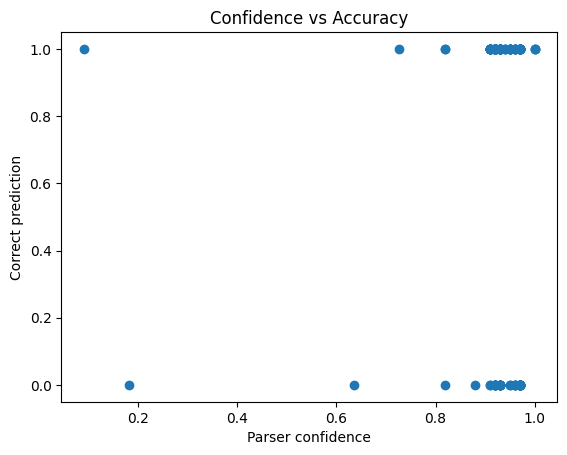

In [27]:
confs = []
correct = []

for ex in dev_split:

    seg = segment_syllogism(ex["syllogism"])
    if seg is None:
        continue

    s1,s2,s3 = seg

    r1,_,_ = parse_statement_dual(s1)
    r2,_,_ = parse_statement_dual(s2)
    r3,_,_ = parse_statement_dual(s3)

    p1,p2,c = r1.prop,r2.prop,r3.prop

    if any(p.q == Q_UNK for p in [p1,p2,c]):
        continue

    conf = min(r1.conf, r2.conf, r3.conf)

    pred = router_predict_one(ex["syllogism"], tau_parse=best_tau)

    confs.append(conf)
    correct.append(int(pred == ex["validity"]))

import matplotlib.pyplot as plt

plt.scatter(confs, correct)
plt.xlabel("Parser confidence")
plt.ylabel("Correct prediction")
plt.title("Confidence vs Accuracy")
plt.show()

In [28]:
from collections import Counter

moods = Counter()

for ex in train_split:

    seg = segment_syllogism(ex["syllogism"])
    if seg is None:
        continue

    s1,s2,s3 = seg
    r1,_,_ = parse_statement_dual(s1)
    r2,_,_ = parse_statement_dual(s2)
    r3,_,_ = parse_statement_dual(s3)

    p1,p2,c = r1.prop,r2.prop,r3.prop

    if any(p.q == Q_UNK for p in [p1,p2,c]):
        continue

    moods[(p1.q,p2.q,c.q)] += 1

print("Top moods:")
print(moods.most_common(10))

Top moods:
[(('ALL', 'ALL', 'SOME'), 63), (('ALL', 'ALL', 'ALL'), 57), (('NO', 'SOME', 'SOME_NOT'), 57), (('ALL', 'NO', 'NO'), 56), (('ALL', 'SOME', 'SOME'), 52), (('NO', 'ALL', 'SOME_NOT'), 51), (('SOME', 'ALL', 'SOME'), 40), (('NO', 'SOME', 'SOME'), 34), (('NO', 'ALL', 'SOME'), 31), (('ALL', 'SOME', 'SOME_NOT'), 28)]


In [29]:
errors = []

for ex in dev_split:

    pred = router_predict_one(ex["syllogism"], tau_parse=best_tau)

    if pred != ex["validity"]:
        errors.append(ex["syllogism"])

print("Number of errors:", len(errors))
print("Sample errors:")
for e in errors[:10]:
    print(e)

Number of errors: 47
Sample errors:
Not a single man is a woman. It is also true that no adult is a man. It follows that no adult is a woman.
Every single person who is a professor is an academic. Any academic is a knowledgeable person. Therefore, some knowledgeable people are professors.
There are no animals that are both fish and warm-blooded. The entire group of mammals consists of animals that are warm-blooded. Fish and mammals are mutually exclusive categories.
Every plant is a living thing. Anything that is an animal is a living thing. It is therefore the case that all animals are plants.
There is no soda that is a juice. A portion of the items that are beverages are not juices. It follows that some beverages are not sodas.
It is the case that no ghost is immortal. There is not a single human that is a ghost. It follows that no human is immortal.
Anything that is a mammal is a living organism. Every single dog is an living organism. This means every dog is a mammal.
Nothing that 